# Snowpack -> Hydropower -> Electricity Prices

**Question:** Does winter/spring California snowpack predict summer electricity
price behavior through hydroelectric generation?

**Panel (data/processed/panel.csv):** one row per year --
`snowpack_pct` (April 1 snow water content as % of normal), summer day-ahead
price features (`price_mean`, `price_peak`, `price_vol`, `price_vol_hourly`),
summer hydro generation (`hydro_gwh`, `hydro_gwh_eia`), and controls
(`temp_mean_c`, `heat_days_38c`, `demand_mean_mw`, `gas_mean`).

**Price window:** 2016-2018 + 2023-2025 (6 years; CAISO's public archive has a
2019-2022 gap). Walk-forward uses min_train=3 -> 3 genuinely held-out years.

## 0. Setup

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.dpi'] = 110

## 1. Load the yearly panel

In [2]:
panel = pd.read_csv(ROOT / 'data' / 'processed' / 'panel.csv', index_col=0)
panel

,snowpack_pct,price_mean,price_peak,price_vol,price_vol_hourly,hydro_gwh,hydro_gwh_eia,temp_mean_c,heat_days_38c
year,,,,,,,,,
1980,142.402576,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1981,77.345168,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1982,140.634217,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1983,229.383654,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1984,91.887505,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1985,98.709872,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1986,138.880178,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1987,58.941742,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1988,33.685457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Snowpack index over time

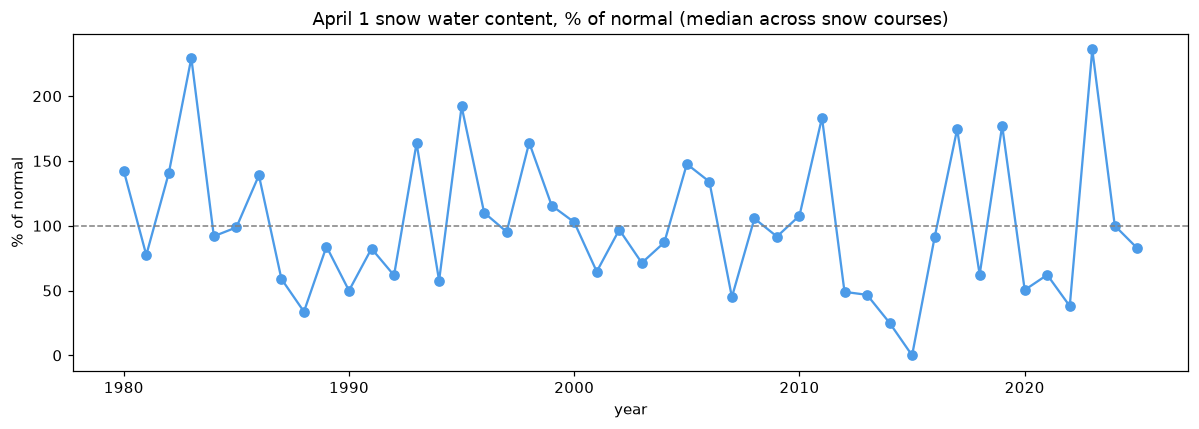

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
panel['snowpack_pct'].plot(ax=ax, marker='o', color='#4c9be8')
ax.axhline(100, color='gray', ls='--', lw=1)
ax.set_title('April 1 snow water content, % of normal (median across snow courses)')
ax.set_ylabel('% of normal')
plt.tight_layout(); plt.show()

## 3. Snowpack vs summer price volatility

          target  pearson_r  spearman_rho  n
      price_mean      0.594         0.257  6
      price_peak      0.547         0.371  6
       price_vol      0.509         0.371  6
price_vol_hourly      0.488         0.371  6


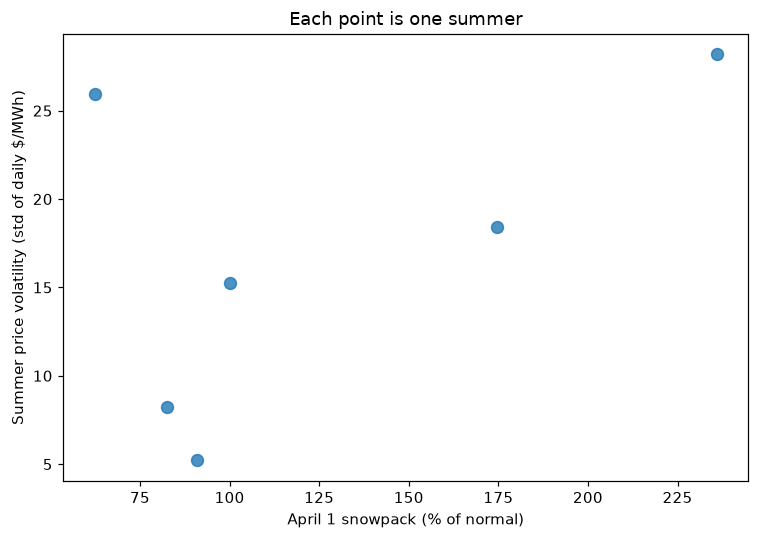

In [4]:
from src.models import correlations

corr = correlations(panel)
print(corr.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 5))
sub = panel.dropna(subset=['snowpack_pct', 'price_vol'])
ax.scatter(sub['snowpack_pct'], sub['price_vol'], s=60, alpha=0.8)
ax.set_xlabel('April 1 snowpack (% of normal)')
ax.set_ylabel('Summer price volatility (std of daily $/MWh)')
ax.set_title('Each point is one summer')
plt.tight_layout(); plt.show()

> EDA takeaway: fill in after running -- does wet years line up with calm
> summers? (Check the sign of `pearson_r` and the scatter direction.)